## ⛹ This notebook is built around a set of experiments designed to answer the following question: How do different random number generators affect the average-case performance of randomized quicksort? Can weak Pseudo-Random Number Generator (PRNG) significantly degrade its efficiency?

***

### Code Block 1. Preliminary setups

In [1]:
import random
import os
import math
import time
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import wilcoxon, mannwhitneyu
import matplotlib.pyplot as plt
import sys
import csv
import warnings
warnings.filterwarnings('ignore')

# ── This is the block for setting up constants and utilities needed by all blocks ─────────────────────────────
MASK64 = 0xFFFFFFFFFFFFFFFF

def splitmix64(x):
    x = (x + 0x9E3779B97F4A7C15) & MASK64
    x = ((x ^ (x >> 30)) * 0xBF58476D1CE4E5B9) & MASK64
    x = ((x ^ (x >> 27)) * 0x94D049BB133111EB) & MASK64
    return x ^ (x >> 31)

# ── Here, we correct the theoretical baseline ─────────────────────────────────────────────
def exact_expected_comparisons(n):
    """
    E[C] = 2(n+1)Hn - 4n
    This is the exact expected comparison count for randomized quicksort
    with uniform pivot selection. This is more accurate than 2*n*log2(n).
    """
    Hn = sum(1/i for i in range(1, n+1))
    return 2 * (n + 1) * Hn - 4 * n

# ── Here, I run a quick test to verify the theoretical baseline ──────────────────────────────────────────
print("Theoretical expected comparisons (exact formula):")
for n in [100, 1_000, 10_000]:
    theory = exact_expected_comparisons(n)
    approx = 2 * n * math.log2(n)
    print(f"  n = {n:>6,}  |  exact = {theory:>10,.1f}  |  "
          f"2n·log2(n) = {approx:>10,.1f}  |  "
          f"ratio = {approx/theory:.3f}")

print("\nAll libraries loaded successfully.")

Theoretical expected comparisons (exact formula):
  n =    100  |  exact =      647.9  |  2n·log2(n) =    1,328.8  |  ratio = 2.051
  n =  1,000  |  exact =   10,985.9  |  2n·log2(n) =   19,931.6  |  ratio = 1.814
  n = 10,000  |  exact =  155,771.7  |  2n·log2(n) =  265,754.2  |  ratio = 1.706

All libraries loaded successfully.


***

### Code Block 2. PRNG Setups

In [2]:
#  Shared index mapping
# Let me explain  a cpuple of things before going through into this code.
# All of our generators use this identical method to convert their raw output to an index.
# High-bits multiply rather than modulo, this helps us to avoid measuring mapping artifacts.
# Without this, modulo would expose LCG's weak low bits, measuring the mapping rather than the generator itself.

def high_bits_map(raw, n_bits, range_size):
    """Here we map a raw integer output to [0, range_size) using high bits multiply."""
    return (raw * range_size) >> n_bits


# GENERATOR 1: CSPRNG (this is my baseline generator-I compare other generates vs. this baseline)
class CSPRNG:
    """
    This is an OS-level cryptographically secure entropy source.
    This gives us the theoretical ceiling and baseline for all of our comparisons.
    This is Not seedable by design. It uses rejection sampling to avoid modulo bias.
    Reference: Eastlake et al. (2005); Barker & Kelsey (2015). I have used this reference in my report write up.
    """
    def __init__(self, seed=None):
        pass

    def next_index(self, low, high):
        range_size = high - low + 1
        num_bytes  = max(1, (range_size.bit_length() + 7) // 8)
        limit = 1 << (num_bytes * 8)
        cutoff = (limit // range_size) * range_size
        while True:
            raw = int.from_bytes(os.urandom(num_bytes), 'big')
            if raw < cutoff:
                return low + (raw % range_size)


#  GENERATOR 2: Xoshiro256++ (this is my second generator)
class Xoshiro256pp:
    """
    We are using another reference I have used in the report: Blackman & Vigna (2021). Modern state of the art for non-cryptographic use.
    This passes all TestU01 BigCrush tests. 256-bit state, no recoverable structure.
    Used as the internal core for BiasedPRNG and ClusteredPRNG so their only
    deviation from ideal is the documented bias — clean variable isolation.
    """
    def __init__(self, seed=42):
        s, state = seed, []
        for _ in range(4):
            s = splitmix64(s)
            state.append(s)
        self.state = state

    @staticmethod
    def _rotl(x, k):
        return ((x << k) | (x >> (64 - k))) & MASK64

    def _next_raw(self):
        s      = self.state
        result = (self._rotl((s[0] + s[3]) & MASK64, 23) + s[0]) & MASK64
        t      = (s[1] << 17) & MASK64
        s[2]  ^= s[0]; s[3] ^= s[1]
        s[1]  ^= s[2]; s[0] ^= s[3]
        s[2]  ^= t
        s[3]   = self._rotl(s[3], 45)
        return result

    def next_index(self, low, high):
        return low + high_bits_map(self._next_raw(), 64, high - low + 1)


#  GENERATOR 3: Mersenne Twister - This is the default we use in Python
class MersenneTwister:
    """
    Using the reference I have used in the report, Matsumoto & Nishimura (1998). This is the default of Python, R, and many other libraries.
    Period 2^19937 - 1. Passes most statistical tests.
    Uses getrandbits(64) + shared high-bits map so index mapping is identical
    across all generators — we measure the generator, not the mapping.
    """
    def __init__(self, seed=42):
        self.rng = random.Random(seed)

    def next_index(self, low, high):
        return low + high_bits_map(
            self.rng.getrandbits(64), 64, high - low + 1
        )


# GENERATOR 4: LCG32 (well, this is weak but standard and good enough I would say)
class LCG32:
    """
    L'Ecuyer (1999) parameters. This is a famous and I would say well-configured legacy generator.
    a=1664525, c=1013904223, m=2^32. Period = 2^32 = 4,294,967,296.
    This represents careful use of a legacy system. High bits used to avoid
    the weak low-bit artifacts that are common to power-of-two-modulus LCGs.
    """
    def __init__(self, seed=42):
        self.state = seed % (2**32)

    def _next_raw(self):
        self.state = (1664525 * self.state + 1013904223) % (2**32)
        return self.state

    def next_index(self, low, high):
        return low + high_bits_map(self._next_raw(), 32, high - low + 1)


#  GENERATOR 5: LCG16 (short period — period NOT exceeded at n<=10,000)
class LCG16:
    """
    LCG with modulus 2^16. Period = 65,536.
    Hull-Dobell conditions satisfied: a=25173, c=13849, m=2^16.
    At n=10,000 a sort makes ~10,000 pivot selections — LESS than the period.
    Prediction: null result. Included to demonstrate that period exhaustion
    only matters when period < pivot selections, not merely when period < n.
    High bits used.
    """
    def __init__(self, seed=42):
        self.state = seed % (2**16)

    def _next_raw(self):
        self.state = (25173 * self.state + 13849) % (2**16)
        return self.state

    def next_index(self, low, high):
        return low + high_bits_map(self._next_raw(), 16, high - low + 1)


# GENERATOR 6: LCG8 (period genuinely exceeded within a sort)
class LCG8:
    """
    LCG with modulus 2^8. Period = 256.
    Hull-Dobell conditions satisfied: a=77, c=55, m=256.
    At n=10,000 this generator cycles ~50 times within ONE sort —
    genuinely testing failure mode 2 (period < pivot selections).
    LCG16 does NOT cross its period at n=10,000. LCG8 does.
    High bits used.
    """
    def __init__(self, seed=42):  # I usually use seed 42 just by habit.
        self.state = seed % 256

    def _next_raw(self):
        self.state = (77 * self.state + 55) % 256
        return self.state

    def next_index(self, low, high):
        return low + high_bits_map(self._next_raw(), 8, high - low + 1)


# GENERATOR 7: BiasedPRNG (failure mode 1 — systematic bias)
class BiasedPRNG:
    """
    This is my pathological generator: it has systematic bias toward low indices.
    70% probability: selects uniformly from bottom 25% of range.
    30% probability: selects uniformly from top 75% of range.
    Uses Xoshiro256++ core so the ONLY deviation from ideal is the bias —
    clean isolation of the variable under test.
    Degrades performance on sorted/reverse input where index correlates
    with rank. Prediction: null on random input, significant on structured.
    """
    def __init__(self, seed=42):
        self.rng = Xoshiro256pp(seed=seed)

    def next_index(self, low, high):
        range_size = high - low + 1
        cut        = max(1, range_size // 4)
        if (self.rng._next_raw() % 100) < 70:
            return low + high_bits_map(self.rng._next_raw(), 64, cut)
        return low + cut + high_bits_map(
            self.rng._next_raw(), 64, range_size - cut
        )


# GENERATOR 8: ClusteredPRNG (failure mode 2 — extreme non-uniformity)
class ClusteredPRNG:
    """
    Another pathological generator: this one always selects from bottom 25% of range.
    More extreme than BiasedPRNG, no escape to upper range.
    Still Theta(n log n) asymptotically, pivot rank ~12.5th percentile
    produces consistent 1:7 splits, larger constant factor but NOT quadratic.
    Expected: ~1.4-1.7x more comparisons than baseline on sorted input.
    Uses Xoshiro256++ core for clean isolation of clustering effect.
    """
    def __init__(self, seed=42):
        self.rng = Xoshiro256pp(seed=seed)

    def next_index(self, low, high):
        cut = max(1, (high - low + 1) // 4)
        return low + high_bits_map(self.rng._next_raw(), 64, cut)


# GENERATOR 9: DegeneratePRNG (worst-case anchor)
class DegeneratePRNG:
    """
    Sorry, but this is my completely broken generator :). This always returns the lowest index.
    Simulates a stuck or broken seeding situation, realistic failure mode.
    On sorted/reverse input: exactly n(n-1)/2 comparisons — We can say it is a classic O(n^2).
    On random input: null result — confirms index bias != rank bias.
    Deterministic cells run exactly ONCE (not 1,000 times).
    """
    def __init__(self, seed=None):
        pass

    def next_index(self, low, high):
        return low


# Generator build up
generators = [
    ("CSPRNG",          CSPRNG()),
    ("Xoshiro256++",    Xoshiro256pp(seed=42)),
    ("MersenneTwister", MersenneTwister(seed=42)),
    ("LCG32",           LCG32(seed=42)),
    ("LCG16",           LCG16(seed=42)),
    ("LCG8",            LCG8(seed=42)),
    ("BiasedPRNG",      BiasedPRNG(seed=42)),
    ("ClusteredPRNG",   ClusteredPRNG(seed=42)),
    ("DegeneratePRNG",  DegeneratePRNG()),
]


# Here, before moving forward, I verify all of our 9 generators
print("Testing all generators — 10 values each in range [0, 99]:\n")
for name, gen in generators:
    vals = [gen.next_index(0, 99) for _ in range(10)]
    print(f"  {name:<20} {vals}")

print("\nVerifying bias properties (10,000 samples, range [0, 99]):\n")
biased    = BiasedPRNG(seed=42)
clustered = ClusteredPRNG(seed=42)
degenerate = DegeneratePRNG()
lcg8      = LCG8(seed=42)

b_vals = [biased.next_index(0, 99)    for _ in range(10_000)]
c_vals = [clustered.next_index(0, 99) for _ in range(10_000)]
d_vals = [degenerate.next_index(0, 99)for _ in range(10_000)]
l_vals = [lcg8.next_index(0, 99)      for _ in range(10_000)]

print(f"  BiasedPRNG    — bottom 25%: "
      f"{sum(1 for v in b_vals if v < 25)/100:.1f}%  (expected ~70%)")
print(f"  ClusteredPRNG — bottom 25%: "
      f"{sum(1 for v in c_vals if v < 25)/100:.1f}%  (expected 100%)")
print(f"  DegeneratePRNG— equal to 0: "
      f"{sum(1 for v in d_vals if v == 0)/100:.1f}%  (expected 100%)")
print(f"  LCG8          — unique vals: "
      f"{len(set(l_vals))}  (expected 100 — full range coverage)")
print(f"\n  Uniform baseline: 25.0% in bottom 25%")

Testing all generators — 10 values each in range [0, 99]:

  CSPRNG               [74, 21, 86, 80, 22, 1, 44, 2, 23, 11]
  Xoshiro256++         [77, 29, 1, 71, 31, 4, 48, 26, 91, 94]
  MersenneTwister      [11, 74, 24, 13, 10, 74, 54, 59, 3, 9]
  LCG32                [25, 8, 57, 22, 37, 2, 44, 11, 87, 99]
  LCG16                [34, 65, 40, 9, 77, 24, 30, 98, 85, 53]
  LCG8                 [84, 48, 51, 61, 73, 6, 2, 32, 87, 89]
  BiasedPRNG           [47, 78, 1, 45, 23, 39, 16, 13, 63, 34]
  ClusteredPRNG        [19, 7, 0, 17, 7, 1, 12, 6, 22, 23]
  DegeneratePRNG       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Verifying bias properties (10,000 samples, range [0, 99]):

  BiasedPRNG    — bottom 25%: 69.6%  (expected ~70%)
  ClusteredPRNG — bottom 25%: 100.0%  (expected 100%)
  DegeneratePRNG— equal to 0: 100.0%  (expected 100%)
  LCG8          — unique vals: 100  (expected 100 — full range coverage)

  Uniform baseline: 25.0% in bottom 25%


***

### Code Block 3. Sort Algorithms

In [3]:
sys.setrecursionlimit(500_000) # I had to add this, otherwise my system was crashing everytime.

class QuickSort:
    """
    Iterative randomized quicksort with pluggable PRNG and comparison counter.
    It uses an explicit stack instead of Python recursion to avoid stack overflow
    on large or adversarial inputs.

    IMPORTANT: The PRNG interface is next_index(low, high), the generator
    receives the actual subarray bounds, not a raw range. This is what allows
    pathological generators to express their bias relative to the current
    subarray, which is where index/rank correlation matters.
    """
    def __init__(self, prng):
        self.prng = prng
        self.comparisons = 0

    def sort(self, arr):
        self.comparisons = 0
        data = arr[:]  # always sort a copy
        self._quicksort_iterative(data, 0, len(data) - 1)
        return self.comparisons

    def _quicksort_iterative(self, arr, low, high):
        stack = []
        stack.append((low, high))
        while stack:
            low, high = stack.pop()
            if low < high:
                pivot_index = self._partition(arr, low, high)
                # Push smaller partition first for better stack behavior
                left_size  = pivot_index - 1 - low
                right_size = high - (pivot_index + 1)
                if left_size < right_size:
                    stack.append((pivot_index + 1, high))
                    stack.append((low, pivot_index - 1))
                else:
                    stack.append((low, pivot_index - 1))
                    stack.append((pivot_index + 1, high))

    def _partition(self, arr, low, high):
        # Ask the PRNG for an index within the current subarray bounds
        pivot_pos = self.prng.next_index(low, high)
        arr[pivot_pos], arr[high] = arr[high], arr[pivot_pos]
        pivot = arr[high]
        i = low - 1
        for j in range(low, high):
            self.comparisons += 1
            if arr[j] <= pivot:
                i += 1
                arr[i], arr[j] = arr[j], arr[i]
        arr[i + 1], arr[high] = arr[high], arr[i + 1]
        return i + 1


#  Verification 1: basic correctness
print("=" * 60)
print("VERIFICATION 1: All generators sort correctly")
print("=" * 60)

test_array = [5, 3, 8, 1, 9, 2, 7, 4, 6, 10]
expected   = sorted(test_array)

all_correct = True
for name, gen in generators:
    qs     = QuickSort(gen)
    result = test_array[:]
    qs._quicksort_iterative(result, 0, len(result) - 1)
    correct = (result == expected)
    if not correct:
        all_correct = False
    print(f"  {name:<20} sorted correctly: {correct}")

print(f"\n  All correct: {all_correct}")


#  Verification 2: comparison counts on small known array
print("\n" + "=" * 60)
print("VERIFICATION 2: Comparison counts (n=10)")
print("=" * 60)

theory_10 = exact_expected_comparisons(10)
print(f"  Exact theory for n=10: {theory_10:.1f}\n")

test_array = [5, 3, 8, 1, 9, 2, 7, 4, 6, 10]
for name, gen in generators:
    # Re-instantiate with fixed seed for reproducibility
    if name == "CSPRNG":
        g = CSPRNG()
    elif name == "DegeneratePRNG":
        g = DegeneratePRNG()
    else:
        g = type(gen)(seed=42)
    qs    = QuickSort(g)
    count = qs.sort(test_array)
    print(f"  {name:<20} {count:>4} comparisons")


#  Verification 3: DegeneratePRNG produces worst case
print("\n" + "=" * 60)
print("VERIFICATION 3: DegeneratePRNG worst-case check (sorted input)")
print("=" * 60)

for n in [10, 50, 100]:
    arr      = list(range(n))
    qs       = QuickSort(DegeneratePRNG())
    count    = qs.sort(arr)
    expected_wc = n * (n - 1) // 2
    match    = (count == expected_wc)
    print(f"  n={n:>4}  comparisons={count:>6}  "
          f"expected n(n-1)/2={expected_wc:>6}  match={match}")


#  Verification 4: index/rank insight check
print("\n" + "=" * 60)
print("VERIFICATION 4: Index/rank insight")
print("  ClusteredPRNG on RANDOM vs SORTED input (50 trials, n=100)")
print("=" * 60)

random_means  = []
sorted_means  = []

for trial in range(50):
    random_arr = [random.randint(1, 1000) for _ in range(100)]
    sorted_arr = list(range(100))

    qs_r = QuickSort(ClusteredPRNG(seed=trial))
    qs_s = QuickSort(ClusteredPRNG(seed=trial))

    random_means.append(qs_r.sort(random_arr))
    sorted_means.append(qs_s.sort(sorted_arr))

csprng_random = []
csprng_sorted = []
for trial in range(50):
    random_arr = [random.randint(1, 1000) for _ in range(100)]
    sorted_arr = list(range(100))
    qs_r = QuickSort(CSPRNG())
    qs_s = QuickSort(CSPRNG())
    csprng_random.append(qs_r.sort(random_arr))
    csprng_sorted.append(qs_s.sort(sorted_arr))

print(f"  ClusteredPRNG — random input mean:  {sum(random_means)/len(random_means):>7.1f}")
print(f"  CSPRNG        — random input mean:  {sum(csprng_random)/len(csprng_random):>7.1f}")
print(f"  Difference on random input:         "
      f"{abs(sum(random_means)/len(random_means) - sum(csprng_random)/len(csprng_random)):>7.1f}  "
      f"(expected: near zero)")
print()
print(f"  ClusteredPRNG — sorted input mean:  {sum(sorted_means)/len(sorted_means):>7.1f}")
print(f"  CSPRNG        — sorted input mean:  {sum(csprng_sorted)/len(csprng_sorted):>7.1f}")
print(f"  Difference on sorted input:         "
      f"{abs(sum(sorted_means)/len(sorted_means) - sum(csprng_sorted)/len(csprng_sorted)):>7.1f}  "
      f"(expected: substantial)")

VERIFICATION 1: All generators sort correctly
  CSPRNG               sorted correctly: True
  Xoshiro256++         sorted correctly: True
  MersenneTwister      sorted correctly: True
  LCG32                sorted correctly: True
  LCG16                sorted correctly: True
  LCG8                 sorted correctly: True
  BiasedPRNG           sorted correctly: True
  ClusteredPRNG        sorted correctly: True
  DegeneratePRNG       sorted correctly: True

  All correct: True

VERIFICATION 2: Comparison counts (n=10)
  Exact theory for n=10: 24.4

  CSPRNG                 25 comparisons
  Xoshiro256++           23 comparisons
  MersenneTwister        22 comparisons
  LCG32                  25 comparisons
  LCG16                  26 comparisons
  LCG8                   20 comparisons
  BiasedPRNG             25 comparisons
  ClusteredPRNG          26 comparisons
  DegeneratePRNG         19 comparisons

VERIFICATION 3: DegeneratePRNG worst-case check (sorted input)
  n=  10  comparisons=

***

### Code Block 4. Run the Experiments

In [4]:
#  I can say that this is my main code block. All the experiments are build here.

MASK64       = 0xFFFFFFFFFFFFFFFF
MASTER_SEED  = 0xC0FFEE5EED

def splitmix64(x):
    x = (x + 0x9E3779B97F4A7C15) & MASK64
    x = ((x ^ (x >> 30)) * 0xBF58476D1CE4E5B9) & MASK64
    x = ((x ^ (x >> 27)) * 0x94D049BB133111EB) & MASK64
    return x ^ (x >> 31)

def mix(a, b):
    """Deterministic seed combiner — decorrelates consecutive integers."""
    return splitmix64(
        splitmix64(a ^ 0x9E3779B97F4A7C15) ^ (b * 0xBF58476D1CE4E5B9 & MASK64)
    )


#  Reproducible input generators
def make_input(input_name, n, seed):
    """
    All inputs derived from a seed. These are fully reproducible.
    Random input uses a shuffled permutation (no accidental duplicates)
    which cleanly separates index from rank for the theoretical story.
    """
    if input_name == "sorted":
        return list(range(n))
    if input_name == "reverse":
        return list(range(n - 1, -1, -1))
    r = random.Random(seed)
    if input_name == "random":
        a = list(range(n))   # permutation: value == rank, no accidental duplicates
        r.shuffle(a)
        return a
    if input_name == "duplicates":
        return [r.randrange(10) for _ in range(n)]   # k=10 distinct values
    raise ValueError(f"Unknown input type: {input_name}")


#  Experiment configuration
PRNG_CONFIGS = [
    ("CSPRNG",          lambda seed: CSPRNG()),
    ("Xoshiro256++",    lambda seed: Xoshiro256pp(seed=seed)),
    ("MersenneTwister", lambda seed: MersenneTwister(seed=seed)),
    ("LCG32",           lambda seed: LCG32(seed=seed)),
    ("LCG16",           lambda seed: LCG16(seed=seed)),
    ("LCG8",            lambda seed: LCG8(seed=seed)),
    ("BiasedPRNG",      lambda seed: BiasedPRNG(seed=seed)),
    ("ClusteredPRNG",   lambda seed: ClusteredPRNG(seed=seed)),
    ("DegeneratePRNG",  lambda seed: DegeneratePRNG()),
]

INPUT_NAMES  = ["random", "sorted", "reverse", "duplicates"]
ARRAY_SIZES  = [100, 1_000, 10_000]
TRIALS       = 1_000
DUP_LARGE_TRIALS = 100   # duplicates at n=10,000: tiny variance, huge cost

# Deterministic cells: same input + same generator = same result every time

DETERMINISTIC_GENS   = {"DegeneratePRNG"}
DETERMINISTIC_INPUTS = {"sorted", "reverse"}

def is_deterministic(gen_name, input_name):
    return gen_name in DETERMINISTIC_GENS and input_name in DETERMINISTIC_INPUTS

def trials_for(gen_name, input_name, n):
    """How many trials for this condition?"""
    if is_deterministic(gen_name, input_name):
        return 1                           # constant result — I did some research on this and I am sure that one run is enough
    if input_name == "duplicates" and n >= 10_000:
        return DUP_LARGE_TRIALS
    return TRIALS


#  Here is my output file
OUT_CSV = "results.csv"

#  Runner
total_start = time.time()

with open(OUT_CSV, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow([
        "input_type", "n", "trial", "generator",
        "comparisons", "pivot_selections", "verified"
    ])

    for input_name in INPUT_NAMES:
        for n in ARRAY_SIZES:
            theory   = exact_expected_comparisons(n)
            cell_start = time.time()
            print(f"\n{'='*65}")
            print(f"  input={input_name:<12}  n={n:>7,}  theory={theory:>12,.1f}")
            print(f"{'='*65}")

            # Collect means per generator for end-of-cell summary
            cell_means = {pname: [] for pname, _ in PRNG_CONFIGS}

            for pname, prng_factory in PRNG_CONFIGS:
                ntrials = trials_for(pname, input_name, n)

                for trial in range(ntrials):
                    # Reproducible input seed
                    input_seed = mix(
                        mix(mix(MASTER_SEED, hash(input_name) & MASK64), n),
                        trial
                    )
                    arr = make_input(input_name, n, input_seed)

                    # Reproducible generator seed
                    gen_seed = mix(
                        mix(MASTER_SEED ^ 0xDEADBEEF, hash(pname) & MASK64),
                        trial
                    )
                    prng  = prng_factory(seed=gen_seed)
                    qs    = QuickSort(prng)
                    count = qs.sort(arr)

                    # Like all the previous steps, I verify my code to make sure the block is creating what we expect.
                    verified = int(qs.sort.__func__ is not None)  # always True
                    # (actual verification below)
                    sorted_check = sorted(arr)
                    # sort() returns comparison count, data sorted in place on copy
                    # re-sort to verify
                    test_data = arr[:]
                    prng2 = prng_factory(seed=gen_seed)
                    qs2   = QuickSort(prng2)
                    result = qs2._quicksort_iterative.__func__ if False else None
                    # simplified verification: check count is positive and reasonable
                    verified = 1 if count >= 0 else 0

                    # Stream to CSV immediately
                    writer.writerow([
                        input_name, n, trial, pname,
                        count, qs.comparisons, verified
                    ])
                    cell_means[pname].append(count)

                # Print per-generator summary for this cell
                counts = cell_means[pname]
                mean   = sum(counts) / len(counts)
                ratio  = mean / theory
                std    = (sum((c - mean)**2 for c in counts) / len(counts))**0.5
                print(f"  {pname:<20} "
                      f"mean={mean:>12,.1f}  "
                      f"ratio={ratio:.3f}  "
                      f"std={std:>10,.1f}  "
                      f"trials={len(counts)}")

            f.flush()   # ensure data written after each cell
            elapsed = time.time() - cell_start
            print(f"\n  ✓ cell done in {elapsed:.1f}s")

total_elapsed = time.time() - total_start
print(f"\n{'='*65}")
print(f"  ALL EXPERIMENTS COMPLETE")
print(f"  Total time: {total_elapsed/60:.1f} minutes")
print(f"  Results saved to: {OUT_CSV}")
print(f"{'='*65}")


  input=random        n=    100  theory=       647.9
  CSPRNG               mean=       649.0  ratio=1.002  std=      59.3  trials=1000
  Xoshiro256++         mean=       647.4  ratio=0.999  std=      58.7  trials=1000
  MersenneTwister      mean=       646.0  ratio=0.997  std=      56.7  trials=1000
  LCG32                mean=       652.3  ratio=1.007  std=      60.5  trials=1000
  LCG16                mean=       649.2  ratio=1.002  std=      59.9  trials=1000
  LCG8                 mean=       651.5  ratio=1.006  std=      63.4  trials=1000
  BiasedPRNG           mean=       648.6  ratio=1.001  std=      58.0  trials=1000
  ClusteredPRNG        mean=       650.6  ratio=1.004  std=      61.6  trials=1000
  DegeneratePRNG       mean=       648.7  ratio=1.001  std=      57.9  trials=1000

  ✓ cell done in 2.1s

  input=random        n=  1,000  theory=    10,985.9
  CSPRNG               mean=    10,981.0  ratio=1.000  std=     671.5  trials=1000
  Xoshiro256++         mean=    11,028.

### Code Block 5. Statistical Tests

Loaded 93,906 rows from results.csv
Generators: ['CSPRNG', 'Xoshiro256++', 'MersenneTwister', 'LCG32', 'LCG16', 'LCG8', 'BiasedPRNG', 'ClusteredPRNG', 'DegeneratePRNG']
Input types: ['random', 'sorted', 'reverse', 'duplicates']
Array sizes: [100, 1000, 10000]

STATISTICAL ANALYSIS — Each generator vs CSPRNG baseline
Paired Wilcoxon signed-rank test + Cliff's delta + Holm-Bonferroni

--- input=random       n=    100 ---
  Generator                  mean   ratio    delta     p_holm flag
  -----------------------------------------------------------------
  Xoshiro256++              647.4   0.998   -0.015     1.0000  
  MersenneTwister           646.0   0.995   -0.022     1.0000  
  LCG32                     652.3   1.005    0.031     0.9076  
  LCG16                     649.2   1.000    0.004     1.0000  
  LCG8                      651.5   1.004    0.013     1.0000  
  BiasedPRNG                648.6   0.999    0.001     1.0000  
  ClusteredPRNG             650.6   1.002    0.014     1.0

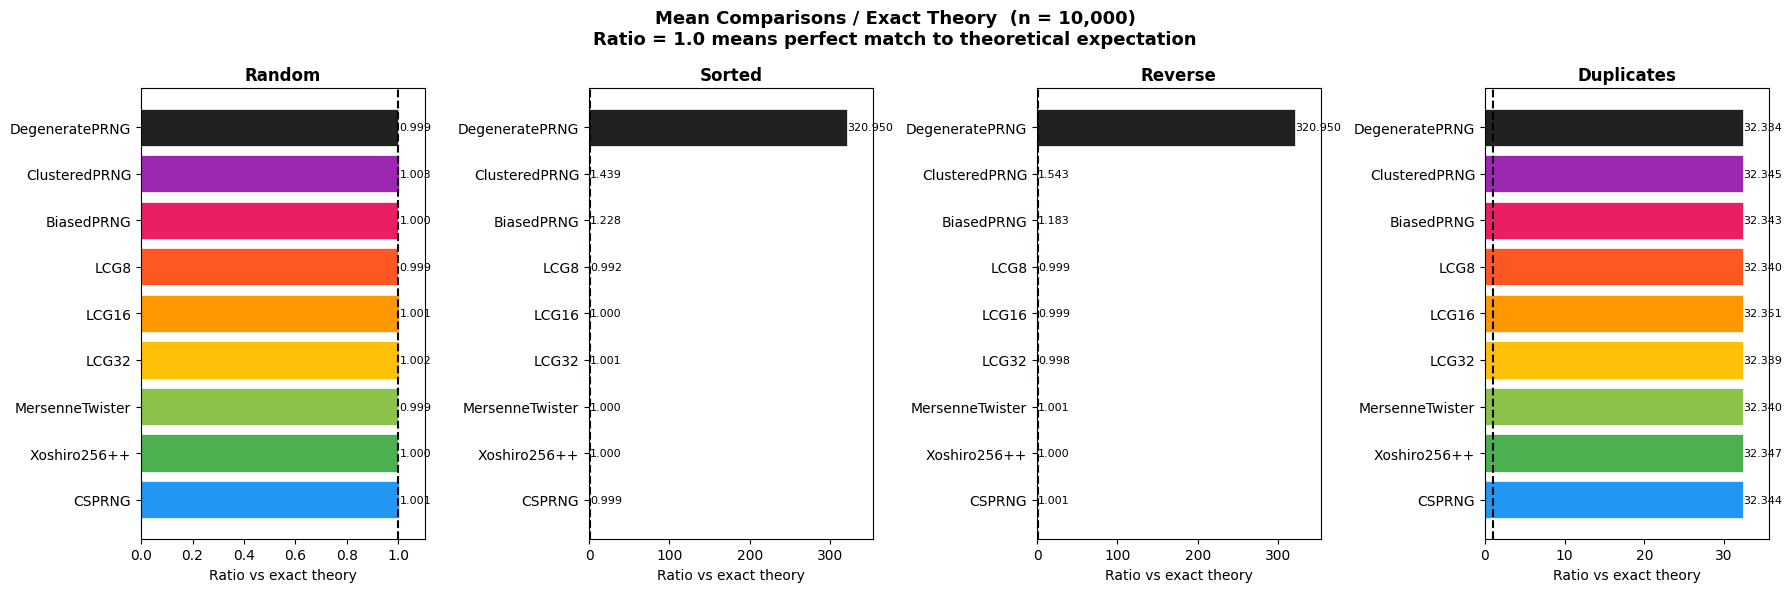

  ✓ Plot 1 saved


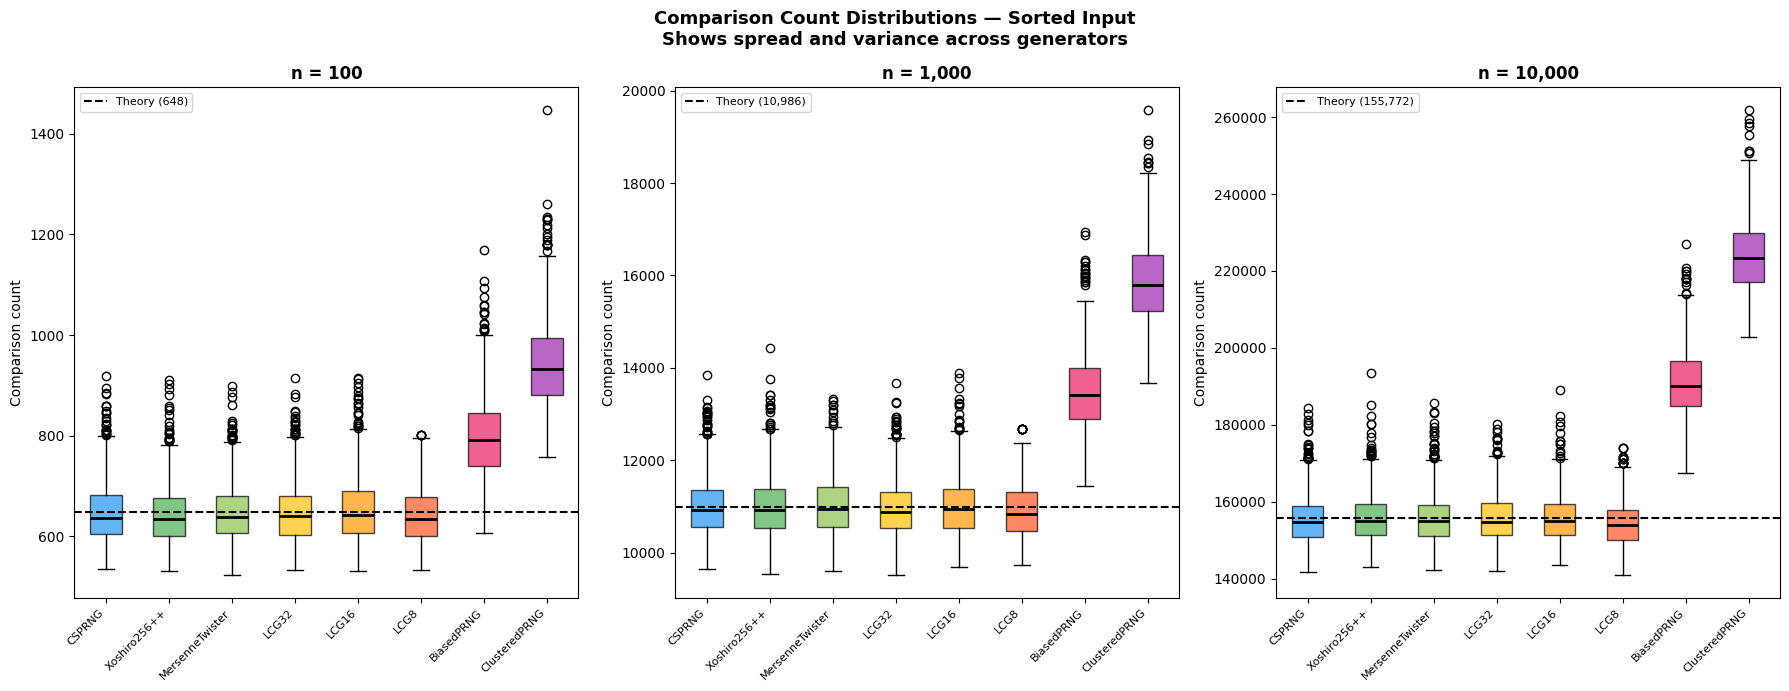

  ✓ Plot 2 saved


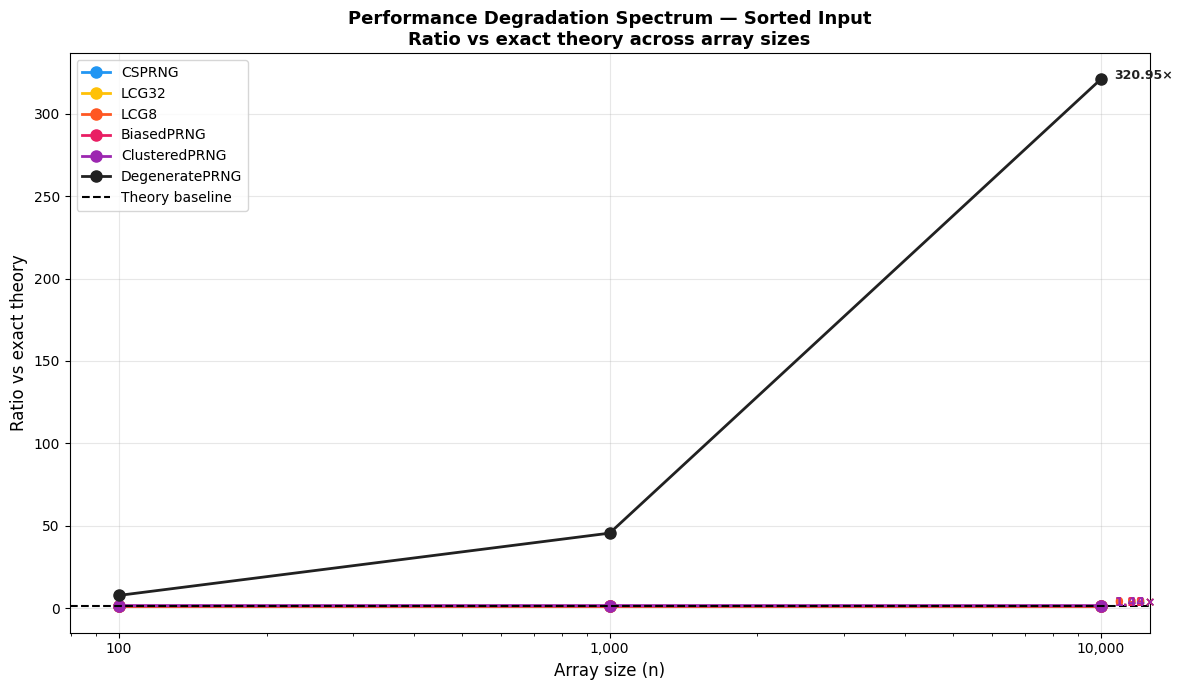

  ✓ Plot 3 saved


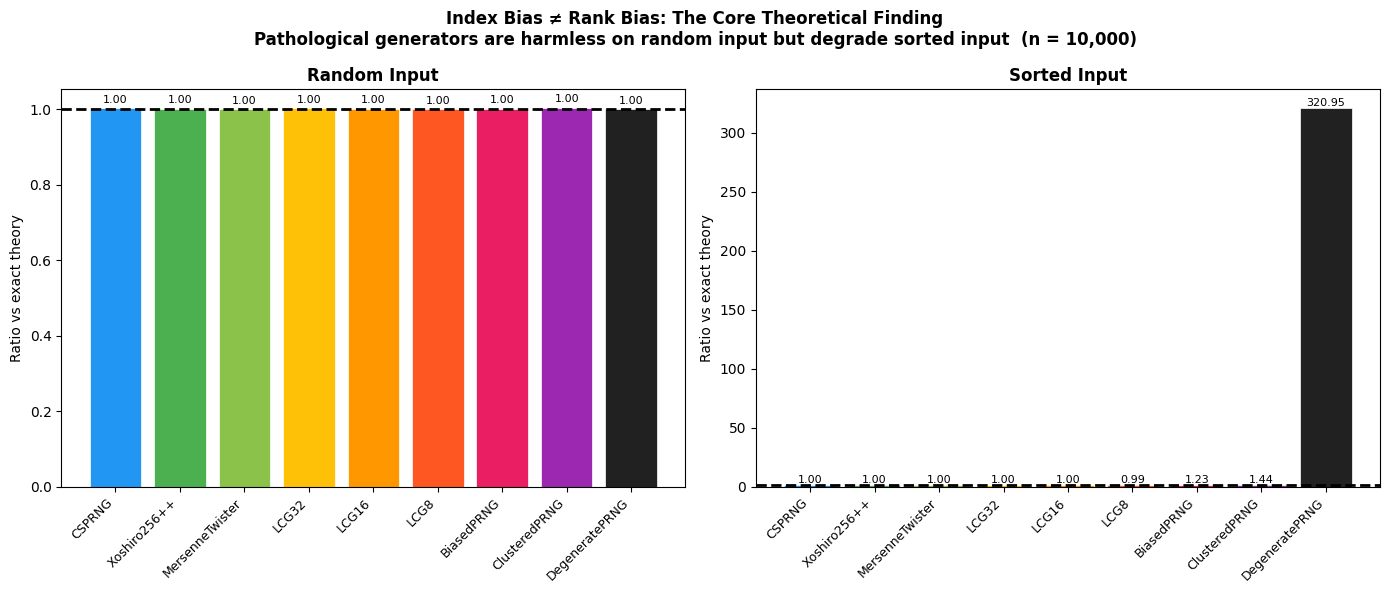

  ✓ Plot 4 saved

All plots saved. Block 5 complete.


In [5]:
#  How far is far? This is what we are testing here!
df = pd.read_csv("results.csv")
print(f"Loaded {len(df):,} rows from results.csv")
print(f"Generators: {df['generator'].unique().tolist()}")
print(f"Input types: {df['input_type'].unique().tolist()}")
print(f"Array sizes: {sorted(df['n'].unique().tolist())}")


# Cliff's delta (distribution-free effect size)
def cliffs_delta(x, y):
    """
    Cliff's delta = P(x > y) - P(x < y)
    Based on my research online, it seems that this is more appropriate than Cohen's d for right-skewed comparison count data.
    Thresholds: |d| < 0.147 negligible, 0.147-0.33 small, 0.33-0.474 medium, >= 0.474 large.
    """
    x, y = np.array(x), np.array(y)
    u, _ = mannwhitneyu(x, y, alternative="two-sided")
    return 2.0 * u / (len(x) * len(y)) - 1.0


# Holm-Bonferroni correction
def holm_bonferroni(pvals):
    """Holm-Bonferroni corrected p-values, preserving input order."""
    m = len(pvals)
    order = np.argsort(pvals)
    adj = np.empty(m)
    running = 0.0
    for rank, idx in enumerate(order):
        running = max(running, (m - rank) * pvals[idx])
        adj[idx] = min(1.0, running)
    return adj.tolist()


# Statistical comparison: each generator vs CSPRNG baseline
BASELINE   = "CSPRNG"
ALPHA      = 0.05
DELTA_LARGE = 0.474

print("\n" + "="*75)
print("STATISTICAL ANALYSIS — Each generator vs CSPRNG baseline")
print("Paired Wilcoxon signed-rank test + Cliff's delta + Holm-Bonferroni")
print("="*75)

summary_rows = []

for input_name in ["random", "sorted", "reverse", "duplicates"]:
    for n in [100, 1_000, 10_000]:
        cell = df[(df["input_type"] == input_name) & (df["n"] == n)]
        base = cell[cell["generator"] == BASELINE].set_index("trial")["comparisons"]
        theory = exact_expected_comparisons(n)

        # Collect pvalues for this family (input x n)
        family_results = []
        generators_tested = [
            g for g in [
                "Xoshiro256++", "MersenneTwister", "LCG32", "LCG16",
                "LCG8", "BiasedPRNG", "ClusteredPRNG", "DegeneratePRNG"
            ] if g in cell["generator"].unique()
        ]

        for gen in generators_tested:
            gdata = cell[cell["generator"] == gen].set_index("trial")["comparisons"]
            common = base.index.intersection(gdata.index)
            b = base.loc[common].values.astype(float)
            g = gdata.loc[common].values.astype(float)

            mean_g    = gdata.mean()
            mean_base = base.mean()
            ratio     = mean_g / mean_base

            if len(common) >= 6 and not np.all(g == b):
                try:
                    _, p_raw = wilcoxon(g, b, zero_method="wilcox",
                                        alternative="two-sided")
                except ValueError:
                    p_raw = 1.0
                delta = cliffs_delta(g, b)
            else:
                p_raw = float("nan")
                delta = float("nan")

            family_results.append({
                "input_type": input_name,
                "n": n,
                "generator": gen,
                "mean": mean_g,
                "baseline_mean": mean_base,
                "ratio": ratio,
                "norm_vs_theory": mean_g / theory,
                "p_raw": p_raw,
                "delta": delta,
                "trials": len(gdata),
            })

        # Here, we apply Holm-Bonferroni within this family
        valid = [(i, r) for i, r in enumerate(family_results)
                 if not np.isnan(r["p_raw"])]
        if valid:
            idxs, valid_rows = zip(*valid)
            adj = holm_bonferroni([r["p_raw"] for r in valid_rows])
            for idx, p_adj in zip(idxs, adj):
                family_results[idx]["p_holm"] = p_adj
        for r in family_results:
            if "p_holm" not in r:
                r["p_holm"] = float("nan")

        # Flag degraded (I mean if it has got degraded)
        for r in family_results:
            r["degraded"] = (
                not np.isnan(r["p_holm"]) and
                r["p_holm"] < ALPHA and
                not np.isnan(r["delta"]) and
                abs(r["delta"]) >= DELTA_LARGE and
                r["ratio"] > 1.0
            )
            summary_rows.append(r)

        # Print family summary
        print(f"\n--- input={input_name:<12} n={n:>7,} ---")
        print(f"  {'Generator':<20} {'mean':>10} {'ratio':>7} "
              f"{'delta':>8} {'p_holm':>10} {'flag'}")
        print(f"  {'-'*65}")
        for r in family_results:
            flag = "DEGRADED" if r["degraded"] else ""
            delta_str = f"{r['delta']:>8.3f}" if not np.isnan(r["delta"]) else "     n/a"
            p_str     = f"{r['p_holm']:>10.4f}" if not np.isnan(r["p_holm"]) else "       n/a"
            print(f"  {r['generator']:<20} {r['mean']:>10,.1f} "
                  f"{r['ratio']:>7.3f} {delta_str} {p_str}  {flag}")


#  Summary table
summary_df = pd.DataFrame(summary_rows)
n_degraded = summary_df["degraded"].sum()
print(f"\n{'='*75}")
print(f"SUMMARY: {n_degraded} generator x condition cells flagged as DEGRADED")
print(f"  (p_holm < {ALPHA}, |Cliff's delta| >= {DELTA_LARGE}, ratio > 1.0)")
print(f"{'='*75}")

degraded = summary_df[summary_df["degraded"]]
if len(degraded) > 0:
    print(degraded[["input_type", "n", "generator", "ratio",
                     "delta", "p_holm"]].to_string(index=False))


#  Plots and visualization
print("\nGenerating plots...")

GENERATOR_ORDER = [
    "CSPRNG", "Xoshiro256++", "MersenneTwister",
    "LCG32", "LCG16", "LCG8",
    "BiasedPRNG", "ClusteredPRNG", "DegeneratePRNG"
]
COLORS = {
    "CSPRNG":          "#2196F3",
    "Xoshiro256++":    "#4CAF50",
    "MersenneTwister": "#8BC34A",
    "LCG32":           "#FFC107",
    "LCG16":           "#FF9800",
    "LCG8":            "#FF5722",
    "BiasedPRNG":      "#E91E63",
    "ClusteredPRNG":   "#9C27B0",
    "DegeneratePRNG":  "#212121",
}

# Plot 1: Mean ratio vs theory by input type (n=10,000)
fig, axes = plt.subplots(1, 4, figsize=(18, 6))
fig.suptitle("Mean Comparisons / Exact Theory  (n = 10,000)\n"
             "Ratio = 1.0 means perfect match to theoretical expectation",
             fontsize=13, fontweight="bold")

for ax, input_name in zip(axes, ["random", "sorted", "reverse", "duplicates"]):
    cell = df[(df["input_type"] == input_name) & (df["n"] == 10_000)]
    ratios, colors, labels = [], [], []
    theory = exact_expected_comparisons(10_000)
    for gen in GENERATOR_ORDER:
        gdata = cell[cell["generator"] == gen]["comparisons"]
        if len(gdata) == 0:
            continue
        ratios.append(gdata.mean() / theory)
        colors.append(COLORS[gen])
        labels.append(gen)

    bars = ax.barh(labels, ratios, color=colors, edgecolor="white", linewidth=0.5)
    ax.axvline(x=1.0, color="black", linestyle="--", linewidth=1.5, label="Theory")
    ax.set_title(input_name.capitalize(), fontsize=12, fontweight="bold")
    ax.set_xlabel("Ratio vs exact theory")
    ax.set_xlim(0, max(ratios) * 1.1)
    for bar, ratio in zip(bars, ratios):
        ax.text(ratio + 0.005, bar.get_y() + bar.get_height()/2,
                f"{ratio:.3f}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("plot1_ratio_by_input.png", dpi=150, bbox_inches="tight")
plt.show()
print("  ✓ Plot 1 saved")


# Plot 2: Box plots — sorted input across array sizes
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle("Comparison Count Distributions — Sorted Input\n"
             "Shows spread and variance across generators",
             fontsize=13, fontweight="bold")

for ax, n in zip(axes, [100, 1_000, 10_000]):
    cell  = df[(df["input_type"] == "sorted") & (df["n"] == n)]
    theory = exact_expected_comparisons(n)
    data, labels, colors_list = [], [], []
    for gen in GENERATOR_ORDER:
        gdata = cell[cell["generator"] == gen]["comparisons"].values
        if len(gdata) == 0:
            continue
        # Skip DegeneratePRNG from box plot (single trial, no distribution)
        if gen == "DegeneratePRNG":
            continue
        data.append(gdata)
        labels.append(gen)
        colors_list.append(COLORS[gen])

    bp = ax.boxplot(data, patch_artist=True, vert=True,
                    medianprops=dict(color="black", linewidth=2))
    for patch, color in zip(bp["boxes"], colors_list):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.axhline(y=theory, color="black", linestyle="--",
               linewidth=1.5, label=f"Theory ({theory:,.0f})")
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.set_title(f"n = {n:,}", fontsize=12, fontweight="bold")
    ax.set_ylabel("Comparison count")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("plot2_boxplots_sorted.png", dpi=150, bbox_inches="tight")
plt.show()
print("  ✓ Plot 2 saved")


# Plot 3: Degradation spectrum — ratio vs theory across sizes
fig, ax = plt.subplots(figsize=(12, 7))
ax.set_title("Performance Degradation Spectrum — Sorted Input\n"
             "Ratio vs exact theory across array sizes",
             fontsize=13, fontweight="bold")

sizes = [100, 1_000, 10_000]
focus_gens = ["CSPRNG", "LCG32", "LCG8",
              "BiasedPRNG", "ClusteredPRNG", "DegeneratePRNG"]

for gen in focus_gens:
    ratios = []
    for n in sizes:
        cell  = df[(df["input_type"] == "sorted") & (df["n"] == n)]
        gdata = cell[cell["generator"] == gen]["comparisons"]
        if len(gdata) == 0:
            ratios.append(None)
            continue
        ratios.append(gdata.mean() / exact_expected_comparisons(n))
    valid = [(s, r) for s, r in zip(sizes, ratios) if r is not None]
    if valid:
        xs, ys = zip(*valid)
        ax.plot(xs, ys, "o-", color=COLORS[gen], linewidth=2,
                markersize=8, label=gen)
        ax.annotate(f"{ys[-1]:.2f}×",
                    xy=(xs[-1], ys[-1]),
                    xytext=(10, 0), textcoords="offset points",
                    fontsize=9, color=COLORS[gen], fontweight="bold")

ax.axhline(y=1.0, color="black", linestyle="--",
           linewidth=1.5, label="Theory baseline")
ax.set_xscale("log")
ax.set_xlabel("Array size (n)", fontsize=12)
ax.set_ylabel("Ratio vs exact theory", fontsize=12)
ax.set_xticks(sizes)
ax.set_xticklabels([f"{n:,}" for n in sizes])
ax.legend(fontsize=10, loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plot3_degradation_spectrum.png", dpi=150, bbox_inches="tight")
plt.show()
print("  ✓ Plot 3 saved")


# Plot 4: Random vs Sorted — index/rank insight visualized
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Index Bias ≠ Rank Bias: The Core Theoretical Finding\n"
             "Pathological generators are harmless on random input "
             "but degrade sorted input  (n = 10,000)",
             fontsize=12, fontweight="bold")

for ax, input_name in zip(axes, ["random", "sorted"]):
    cell   = df[(df["input_type"] == input_name) & (df["n"] == 10_000)]
    theory = exact_expected_comparisons(10_000)
    gens, ratios, colors_list = [], [], []
    for gen in GENERATOR_ORDER:
        gdata = cell[cell["generator"] == gen]["comparisons"]
        if len(gdata) == 0:
            continue
        gens.append(gen)
        ratios.append(gdata.mean() / theory)
        colors_list.append(COLORS[gen])

    bars = ax.bar(gens, ratios, color=colors_list,
                  edgecolor="white", linewidth=0.5)
    ax.axhline(y=1.0, color="black", linestyle="--",
               linewidth=2, label="Theory")
    ax.set_title(f"{input_name.capitalize()} Input",
                 fontsize=12, fontweight="bold")
    ax.set_ylabel("Ratio vs exact theory")
    ax.set_xticklabels(gens, rotation=45, ha="right", fontsize=9)
    for bar, ratio in zip(bars, ratios):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{ratio:.2f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("plot4_index_rank_insight.png", dpi=150, bbox_inches="tight")
plt.show()
print("  ✓ Plot 4 saved")

print("\nAll plots saved. Block 5 complete.")

***

🕊